In [1]:
from unittest.util import unorderable_list_difference

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ad_spend.csv')
df.head()

,Ad Spend ($),Season,Revenue ($)
0,463,Monsoon,440
1,158,Winter,297
2,328,Monsoon,214
3,322,Monsoon,48
4,726,Winter,1048


In [2]:
df.shape

(200, 3)

In [5]:
g = df.groupby('Season')[['Ad Spend ($)', 'Revenue ($)']].mean()

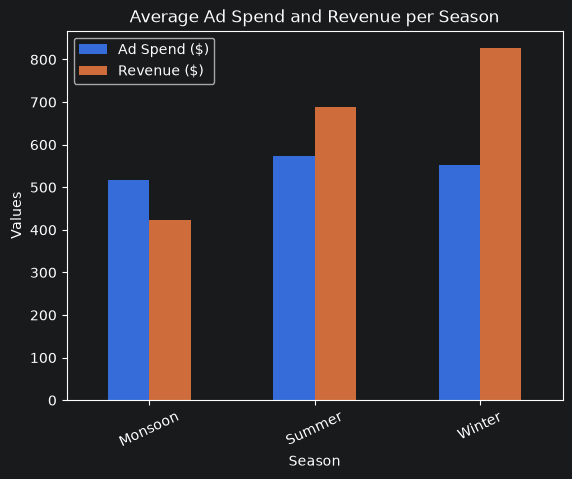

In [8]:
ax = g.plot(kind='bar')
ax.set_title('Average Ad Spend and Revenue per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Values')

plt.xticks(rotation=25)  # Rotate x-axis labels for better readability
plt.show()

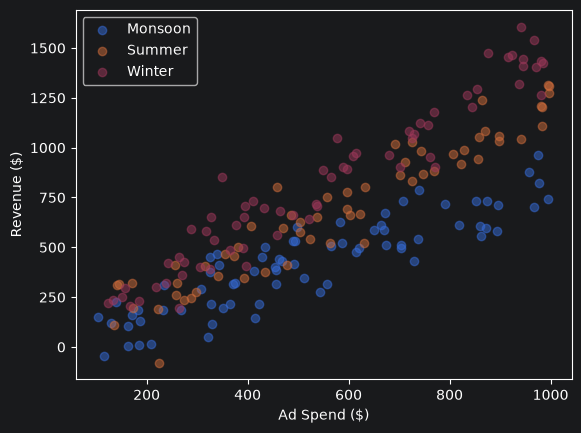

In [9]:
for season, subdf in df.groupby('Season'):
    plt.scatter(subdf['Ad Spend ($)'], subdf['Revenue ($)'], label=season, alpha=0.5)
plt.xlabel('Ad Spend ($)')
plt.ylabel('Revenue ($)')
plt.legend()
plt.show()

In [10]:
df_encoded = pd.get_dummies(df, columns=['Season'], drop_first=True)
df_encoded.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded[["Ad Spend ($)", "Season_Summer", "Season_Winter"]]
y = df_encoded["Revenue ($)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8882097000477289

In [13]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8972778553142061

In [39]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators=60)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9162014487827526

In [15]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)

mean_squared_error(y_test, y_pred)

14075.189625267236

In [16]:
df_eval = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df_eval.head(3)

,Actual,Predicted
59,605,677.144222
5,1125,1073.575312
20,699,626.698237


In [18]:
df_eval['Diff %'] = abs((df_eval['Predicted'] - df_eval['Actual'])*100/df_eval['Actual'])
df_eval

,Actual,Predicted,Diff %
59,605,677.144222,11.924665
5,1125,1073.575312,4.571083
20,699,626.698237,10.343600
198,504,418.202801,17.023254
52,1310,1134.088133,13.428387
19,320,170.512121,46.714962
162,944,1016.629203,7.693771
55,581,747.372975,28.635624
69,1446,1419.638973,1.823031
2,214,344.868149,61.153341


In [19]:
df_eval['Diff %'].quantile(0.75)

np.float64(25.419922596675747)